This is for algorithmic experimentation for how to produce an appropriate phoenix-based 1d spectrum in ~1 ms or less.

This attempt is to use an INR to do the above.

In [2]:
import pickle
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy import units as u
from astropy.io import fits   

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
rkey = jax.random.PRNGKey(42)
jax.devices()

[CudaDevice(id=0)]

# Single spectrum experiments

Start working with just a single spectrum and ignore its parameters - can we make this work with just a single coordinate encoding wavelength?

The spectrum here is derived in [single_forward_model2_phmodel](single_forward_model2_phmodel.ipynb) 

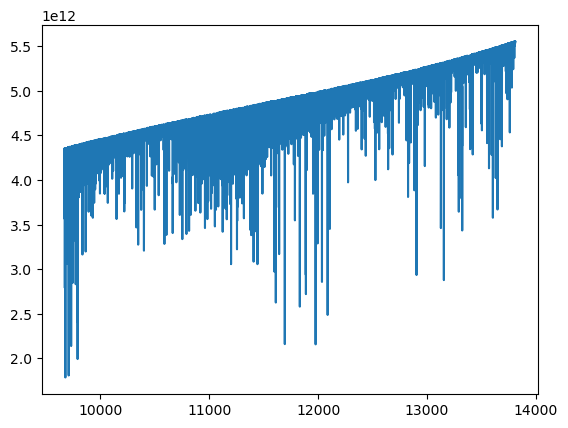

In [3]:
with open('single_forward_model_model_spec.pkl', 'rb') as f:
    data = pickle.load(f)

model_wave = data['wave']
model_flux = data['model']
model_path = data['phoenix_path']

# note that the normalization is at the "surface" of the star, so its crazy high - renormalize as needed
model_flux_fnu = model_flux.to(u.MJy, equivalencies=u.spectral_density(model_wave)) 

del data

plt.plot(model_wave, model_flux_fnu);

Use a WIRE-style INR. 

## WIRE INR

In [4]:
class GaborLayer(eqx.Module):
    w0: float
    s0: float
    lin1: eqx.nn.Linear
    #lin2: eqx.nn.Linear
    
    def __init__(self, nin, nout, w0=20, s0=10, rkey=None,trainable0s=True):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rk1, = jax.random.split(rkey, 1)
        self.lin1 = eqx.nn.Linear(nin, nout, key=rk1)

        if trainable0s:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
            self.s0 = jnp.array(s0, dtype=jnp.float32)
        else:
            self.w0 = w0
            self.s0 = s0

    def __call__(self, x):
        x1 = self.lin1(x)

        return self.nonlinearity(x1)


class ComplexGaborLayer(GaborLayer):
    def nonlinearity(self, x1):
        t1 = x1 * (self.w0 * 1j)

        z = x1 * self.s0
        #t2 = jnp.abs(z)**2
        #t2 = z * z.conj()
        t2 = jnp.real(z)**2 + jnp.imag(z)**2
        return jnp.exp(t1-t2)


class WIRE(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       rkey=None,
                       w0=20, s0=10,
                       trainable_activation_params=False):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        layers = [GausslessGaborLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                     w0=w0, s0=s0, trainable0s=trainable_activation_params)]
        for i in range(num_hidden_layers):
            layers.append(GausslessGaborLayer(hidden_size, hidden_size, rkey=rkeys[i+1],
                          w0=w0, s0=s0, trainable0s=trainable_activation_params))

        layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(jnp.real)
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  


class Normalizer:
    def __init__(self, coord):
        self.min = jnp.min(coord)
        self.scale = jnp.ptp(coord)

    def normalize(self, coord):
        return (coord - self.min)/self.scale * 2 - 1
    
    def denormalize(self, norm_coord):
        return (norm_coord + 1)/2 * self.scale + self.min

### Prep data

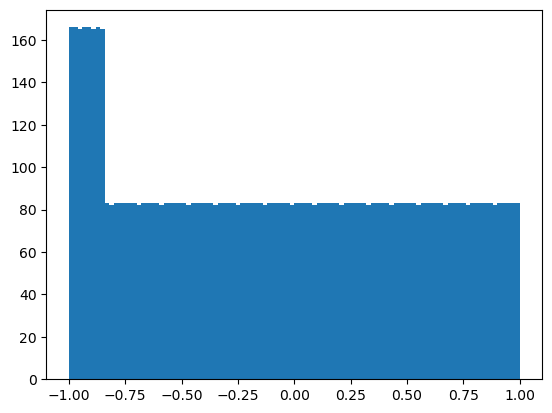

In [5]:
wlnorm = Normalizer(model_wave.value)
model_wave_norm = wlnorm.normalize(model_wave.value)
plt.hist(model_wave_norm, bins=100);

We normalize the flux to 0-1 for the sigmoid last activation.

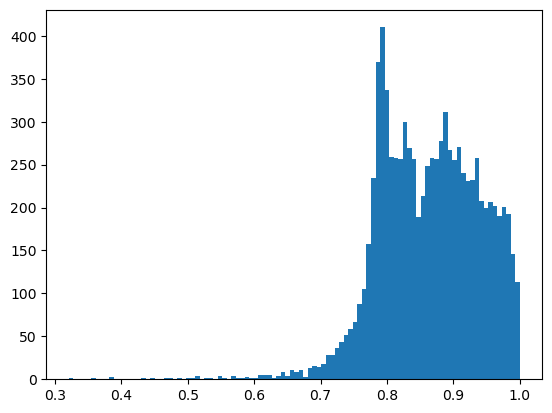

In [6]:
model_flux_fnu_scale = jnp.max(model_flux_fnu.value)
model_flux_fnu_norm = model_flux_fnu.value/model_flux_fnu_scale
plt.hist(model_flux_fnu_norm, bins=100);

### Fit

  0%|          | 0/5000 [00:00<?, ?it/s]

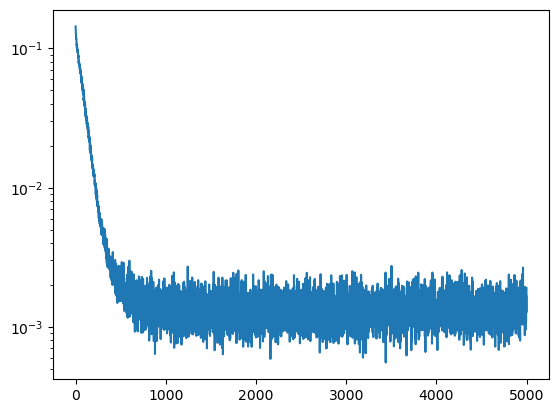

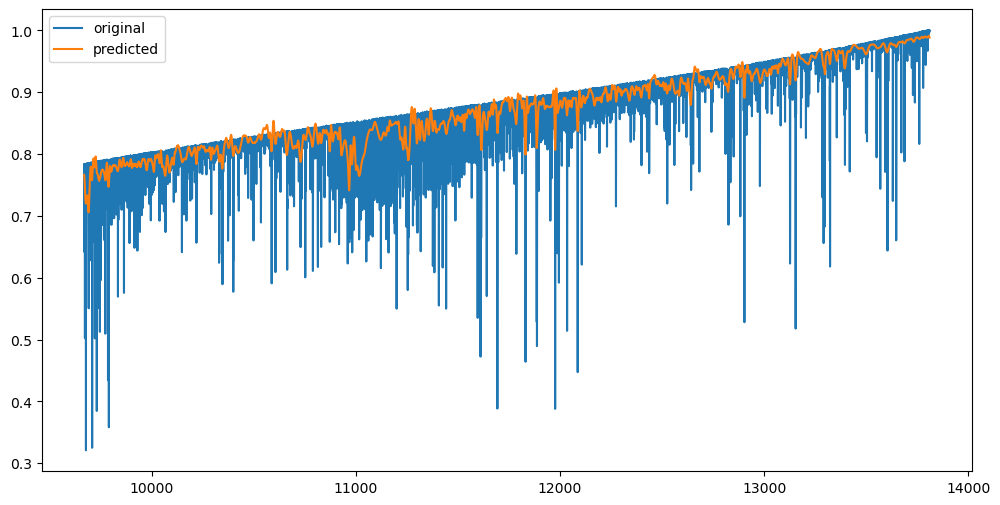

In [87]:
LEARNING_RATE = 1e-4
EPOCHS = 5000
BATCH_SIZE = 512

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = WIRE(s0=10, w0=20, hidden_size=128, num_hidden_layers=2, n_in_coo=1, rkey=skey) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = jnp.array(model_flux_fnu_norm)

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypred, label='predicted')
plt.legend()

Ok that didn't work.  Try a [-1,1] normalization on the output layer.  Needs tanh as final activation.

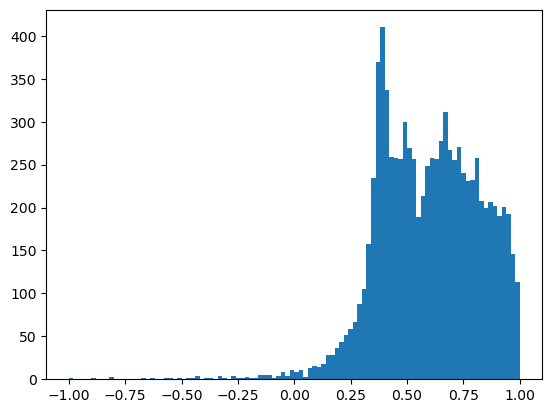

In [81]:
fluxnorm = Normalizer(model_flux_fnu.value)
model_flux_fnu_norm2 = fluxnorm.normalize(model_flux_fnu.value)
plt.hist(model_flux_fnu_norm2, bins=100);

  0%|          | 0/5000 [00:00<?, ?it/s]

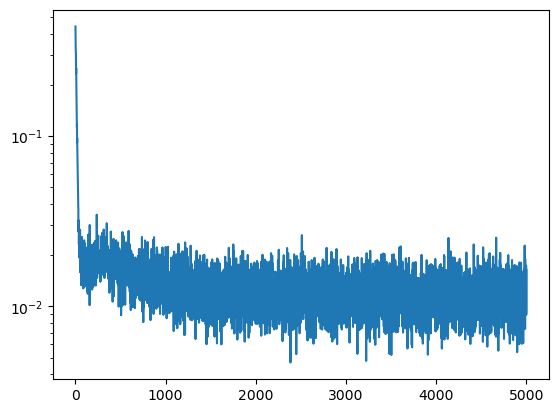

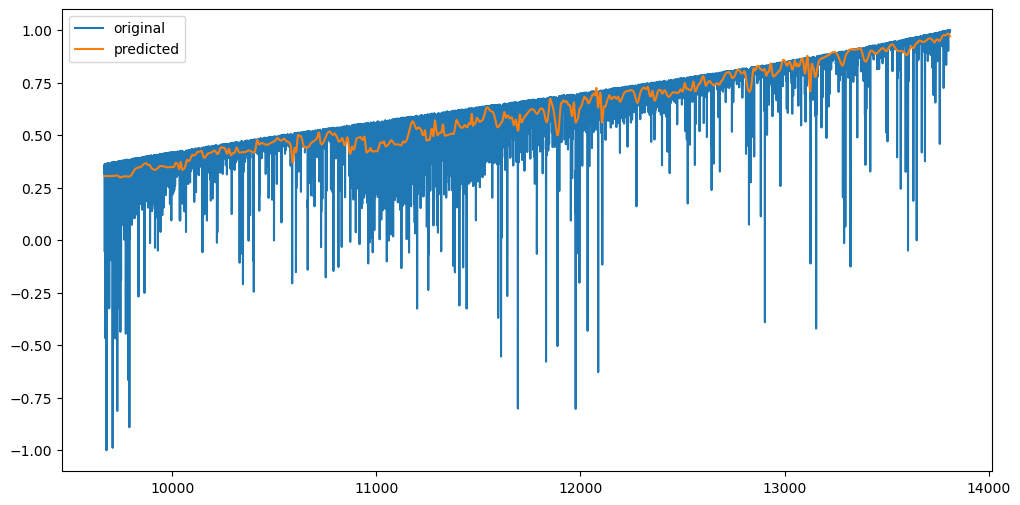

In [94]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 512

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = WIRE(s0=10, w0=20, hidden_size=128, num_hidden_layers=2, n_in_coo=1, rkey=skey, final_activation=jax.nn.tanh) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = jnp.array(model_flux_fnu_norm2)

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
plt.plot(model_wave.value, model_flux_fnu_norm2, label='original')
plt.plot(model_wave.value, ypred, label='predicted')
plt.legend()

Still not capturing things correctly.  Lets try a SIREN-like approach, since that's supposed to be better at audio where high frequencies matter

In [10]:
class SIRENLayer(eqx.Module):
    w0: float
    lin: eqx.nn.Linear
    
    def __init__(self, nin, nout, w0,  nl, firstlayer, rkey=None, trainable0s=False):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        if trainable0s:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
        else:
            self.w0 = w0

        self.lin = self.siren_init_lin(nin, nout, nl, firstlayer, rkey)

    def __call__(self, x):
        x1 = self.lin(x)
        return jnp.sin(self.w0 * x1)

    def siren_init_lin(self, nin, nout, nl, firstlayer, rkey):
        rk1, rk2 = jax.random.split(rkey, 2)

        # the key doesn't actually matter since we are re-initializing below
        init_lin = eqx.nn.Linear(nin, nout, key=rkey)

        if firstlayer:
            u_upper = 1/nout * self.w0
        else:
            u_upper = jnp.sqrt(6/nin) * self.w0

        newws = jax.random.uniform(rk1, init_lin.weight.shape, minval=-u_upper, maxval=u_upper)
        new_linear = eqx.tree_at(lambda l: l.weight, init_lin, newws)

        newbs = jax.random.uniform(rk2, init_lin.bias.shape, minval=-jnp.pi, maxval=jnp.pi)
        return eqx.tree_at(lambda l: l.bias, new_linear, newbs)


class SIREN(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       rkey=None,
                       w0=30,
                       trainable_activation_params=False):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        layers = [SIRENLayer(n_in_coo, hidden_size, 
                             rkey=rkeys[0],
                             w0=w0, nl=num_hidden_layers,
                             firstlayer=True,
                             trainable0s=trainable_activation_params)]
        for i in range(num_hidden_layers):
            layers.append(SIRENLayer(hidden_size, hidden_size,
                                     rkey=rkeys[i+1],
                                     w0=w0, nl=num_hidden_layers, 
                                     firstlayer=False,
                                     trainable0s=trainable_activation_params))

        layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(jnp.real)
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  

  0%|          | 0/5000 [00:00<?, ?it/s]

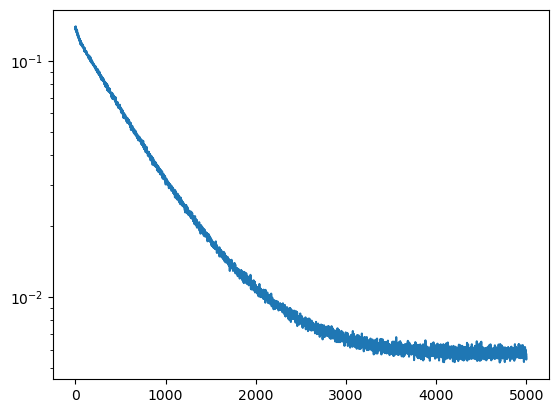

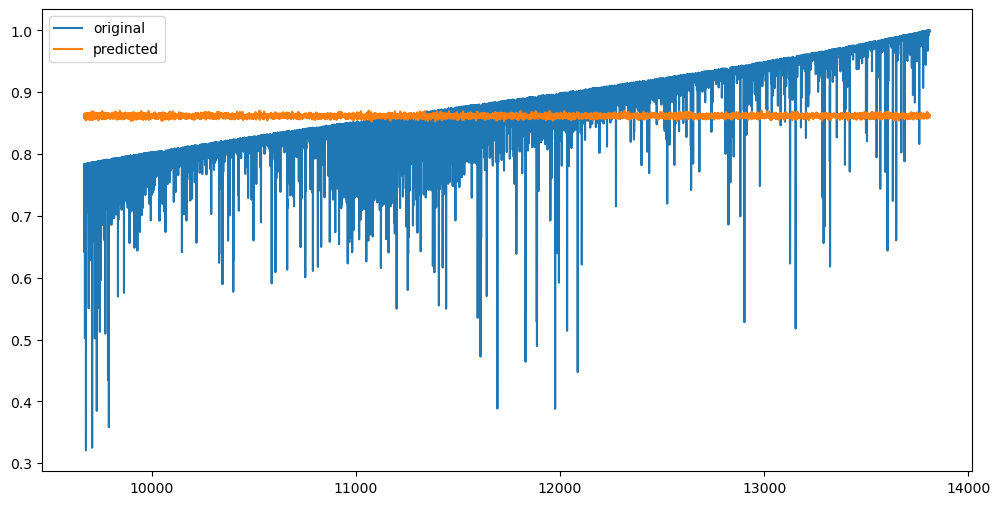

In [11]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = SIREN(w0=100, hidden_size=128, num_hidden_layers=3, n_in_coo=1, rkey=skey) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = jnp.array(model_flux_fnu_norm)

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypred, label='predicted')
plt.legend()

Hmph.  Maybe the approach of https://arxiv.org/html/2606.23129v2 will work better?

# FDHO INR

FDHO as implemented but with a skip connection to better capture low frequencies

In [ ]:
def inv_softplus(s):
    return jnp.log(jnp.exp(s) - 1)

class FDHOLayer(eqx.Module):
    lin: eqx.nn.Linear
    freq_params: jnp.ndarray # (ω', ωn')
    nonfreq_params: jnp.ndarray # (ξ, φ)

    def __init__(self, nin, nout, 
                 w0, wn0, xi0, phi0,
                 firstlayer,
                 rkey=None,trainable0s=True):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        if phi0 is None:
            # from the paper - physical lag of an oscillator with the other given parameters
            phi0 = -jnp.arctan2(2*xi0*w0*wn0, (wn0**2 - w0**2))

        wp0 = inv_softplus(w0)
        wnp0 = inv_softplus(wn0)
        self.freq_params = jnp.array([wp0, wnp0], dtype=jnp.float32)
        
        self.nonfreq_params = jnp.array([xi0, phi0], dtype=jnp.float32)

        rk1, = jax.random.split(rkey, 1)
        self.lin = self.init_lin(nin,nout, firstlayer, wn0, rk1)
        self.lin = eqx.nn.Linear(nin, nout, key=rk1)

    def init_lin(self, nin, nout, firstlayer, wn0, rkey):
        rk1, rk2 = jax.random.split(rkey, 2)

        init_lin = eqx.nn.Linear(nin, nout, key=rk1)

        if firstlayer:
            layerscale = jnp.sqrt(6/nout)
        else:
            layerscale = jnp.sqrt(jnp.sqrt(6/nin) / wn0)

        new_weights = jax.random.uniform(rk2, init_lin.weight.shape, minval=-layerscale, maxval=layerscale)

        return eqx.tree_at(lambda l: l.weight, init_lin, new_weights)

    def __call__(self, x):
        z = self.lin(x)

        ω, ωn = jax.nn.softplus(self.freq_params)
        ξ, φ = self.nonfreq_params
        
        A = ωn**2/jnp.hypot(ωn**2 - ω**2, 2* ξ * ωn * ω)
        return A*jnp.sin(ω * z + φ)


class FDHO(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       w0=40, wn0=45, xi0=2**-0.5, phi0=None,
                       rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        layers = [FDHOLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                            w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=True)]
        for i in range(num_hidden_layers):
            layers.append(FDHOLayer(hidden_size, hidden_size, rkey=rkeys[i+1], 
                                    w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=False))

        layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(jnp.real)
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  

  0%|          | 0/5000 [00:00<?, ?it/s]

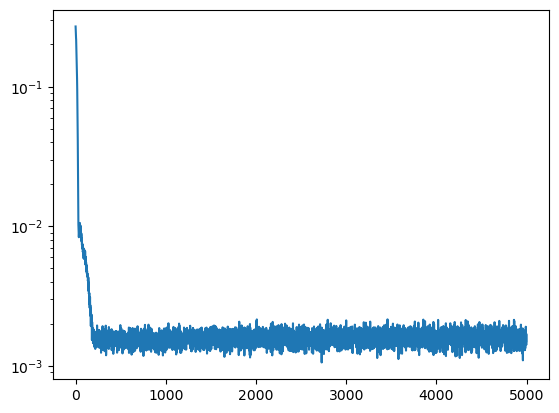

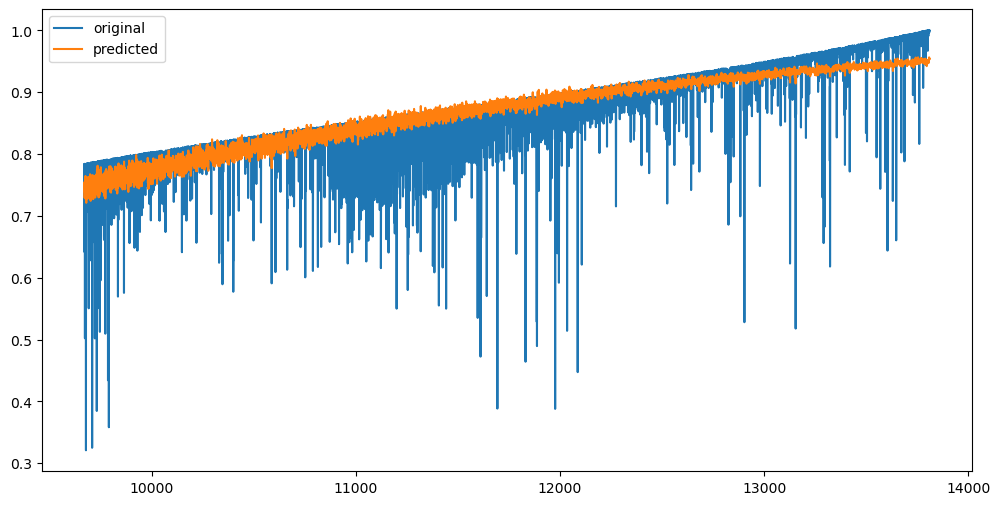

In [34]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=1, rkey=skey)
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = jnp.array(model_flux_fnu_norm)

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypred, label='predicted')
plt.legend()

  0%|          | 0/15000 [00:00<?, ?it/s]

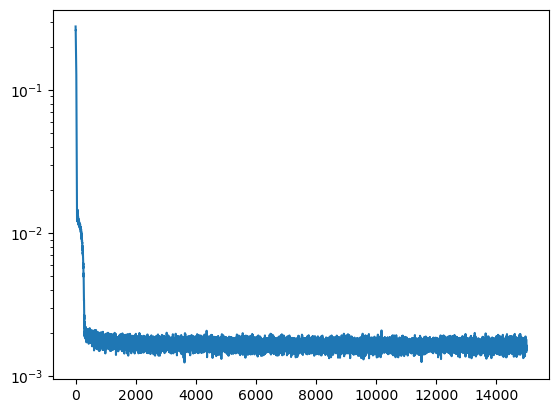

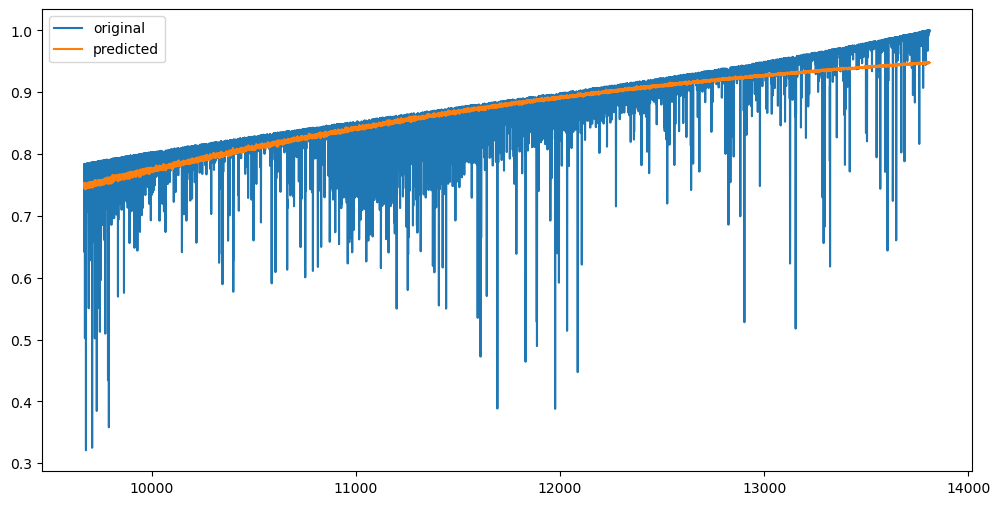

In [35]:
LEARNING_RATE = 5e-4
EPOCHS = 15000
BATCH_SIZE = 2048*2

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=1, rkey=skey, num_hidden_layers=3, hidden_size=512) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = jnp.array(model_flux_fnu_norm)

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypred, label='predicted')
plt.legend()

Hmm, with the expand capacity it struggles with the tilt.  Try adding a skip connection

In [37]:
class FDHOWithSkip(eqx.Module):
    mlp_layers: list
    skip_lin: eqx.nn.Linear
    final_lin: eqx.nn.Linear
    final_activation: callable

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       w0=40, wn0=45, xi0=2**-0.5, phi0=None,
                       rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        layers = [FDHOLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                            w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=True)]
        for i in range(num_hidden_layers):
            layers.append(FDHOLayer(hidden_size, hidden_size, rkey=rkeys[i+1], 
                                    w0=w0, wn0=wn0, xi0=xi0, phi0=phi0, firstlayer=False))

        self.mlp_layers = layers
        self.final_lin = eqx.nn.Linear(hidden_size, 1, key=rkeys[-1])
        self.final_activation = final_activation

        self.skip_lin = eqx.nn.Linear(n_in_coo, hidden_size, key=rkeys[-1])
        
    def __call__(self, x):
        mlp_x = x
        for layer in self.mlp_layers:
            mlp_x = layer(mlp_x)
        skip_x = self.skip_lin(x)
        x = mlp_x + skip_x
        x = self.final_lin(x)
        return self.final_activation(x).squeeze()

  0%|          | 0/15000 [00:00<?, ?it/s]

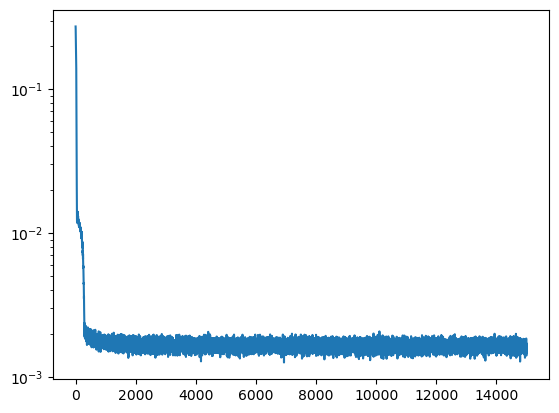

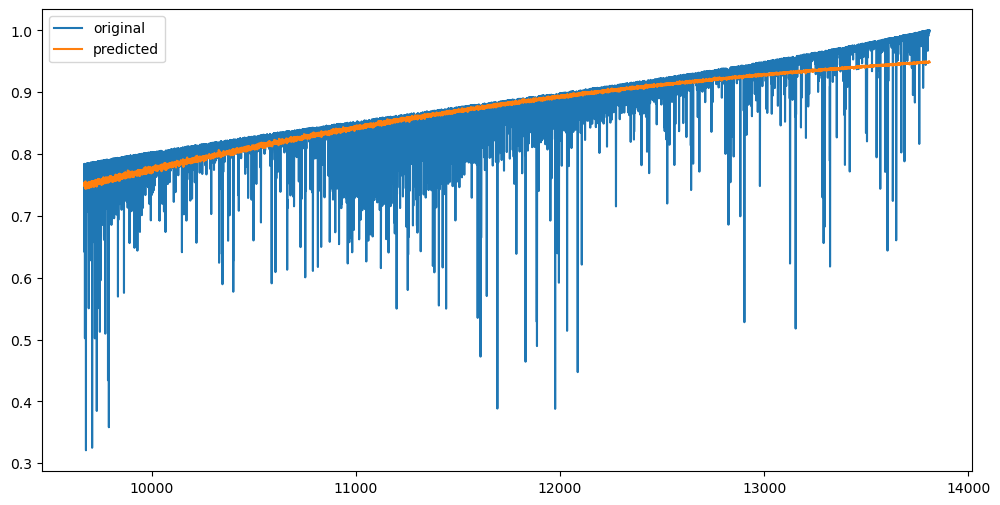

In [38]:
LEARNING_RATE = 5e-4
EPOCHS = 15000
BATCH_SIZE = 2048*2

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHOWithSkip(n_in_coo=1, rkey=skey, num_hidden_layers=3, hidden_size=512) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = jnp.array(model_flux_fnu_norm)

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypred, label='predicted')
plt.legend()

Also try just manually de-trending instead of skip connection

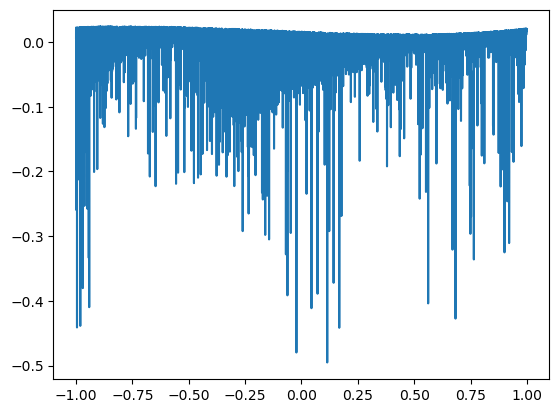

In [ ]:
ys = jnp.array(model_flux_fnu_norm)

X = jnp.vstack([xs.ravel(), jnp.ones(xs.size)]).T
m, b = jnp.linalg.lstsq(X, ys)[0]

ysdt = ys - (m*xs[:, 0] + b)

  0%|          | 0/25000 [00:00<?, ?it/s]

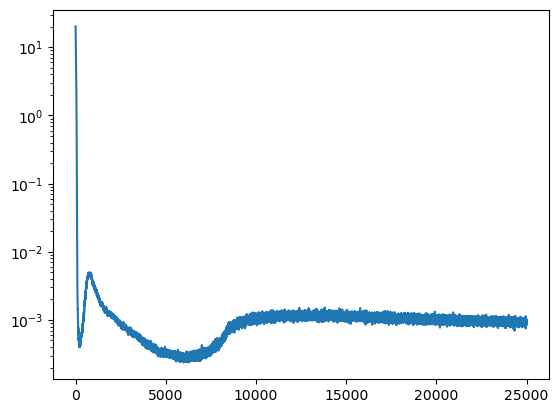

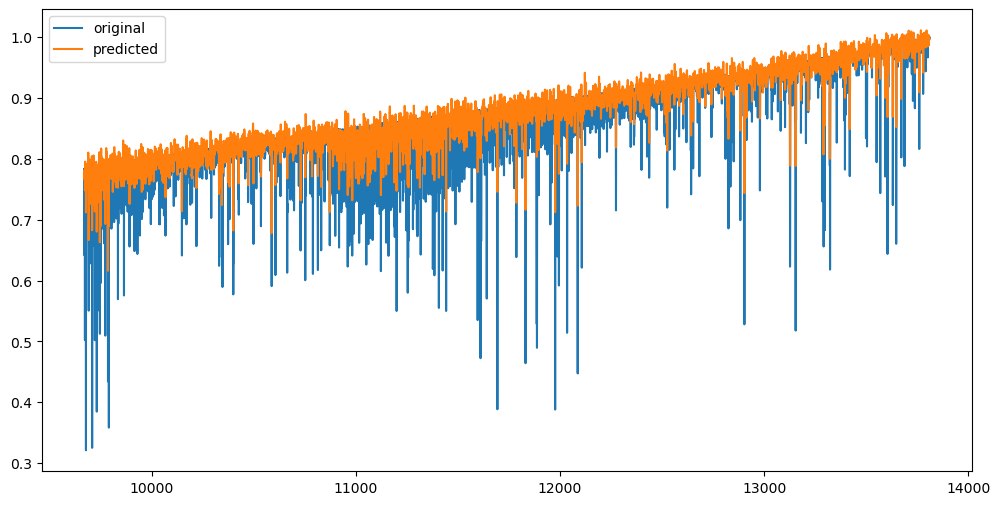

In [66]:
LEARNING_RATE = 5e-4
EPOCHS = 25000
BATCH_SIZE = 2048*2

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=1, rkey=skey, num_hidden_layers=2, hidden_size=512, final_activation=jax.nn.identity) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = ysdt

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
ypreddt = ypred + (m*xs[:, 0] + b)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypreddt, label='predicted')
plt.legend()

Is fitting reasonably well, but the spikes above the ceiling are a problem. Try adding a ceiling-exceeding penalty

  0%|          | 0/25000 [00:00<?, ?it/s]

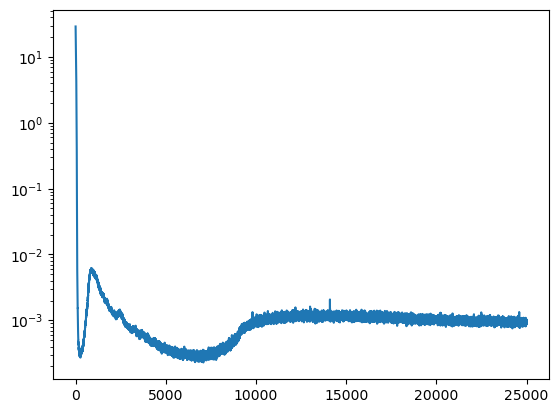

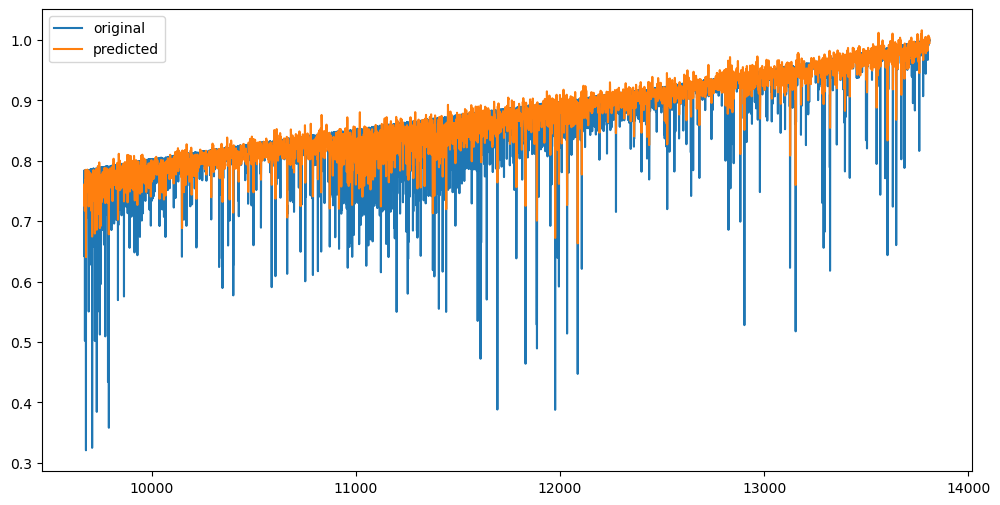

In [ ]:
LEARNING_RATE = 5e-4
EPOCHS = 25000
BATCH_SIZE = 2048*2

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)


def mse_ceiling_loss_fn(model, x, y, ceiling=0, ceiling_power=2):
    y_pred = jax.vmap(model)(x)
    mse = (y_pred - y)**2
    ceiling_term = jax.nn.relu(y_pred - ceiling)**ceiling_power
    return jnp.mean(mse + ceiling_term)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, ceiling=0, ceiling_power=2):
    loss, grads = eqx.filter_value_and_grad(mse_ceiling_loss_fn)(model, x, y, ceiling, ceiling_power)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=1, rkey=skey, num_hidden_layers=2, hidden_size=512, final_activation=jax.nn.identity) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = ysdt

ysmax = ys.max()

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, ceiling=ysmax, ceiling_power=2)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
ypreddt = ypred + (m*xs[:, 0] + b)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypreddt, label='predicted')
plt.legend()

Or a pinball style loss

  0%|          | 0/250000 [00:00<?, ?it/s]

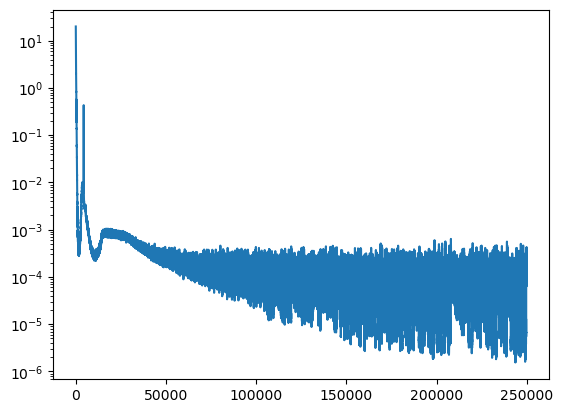

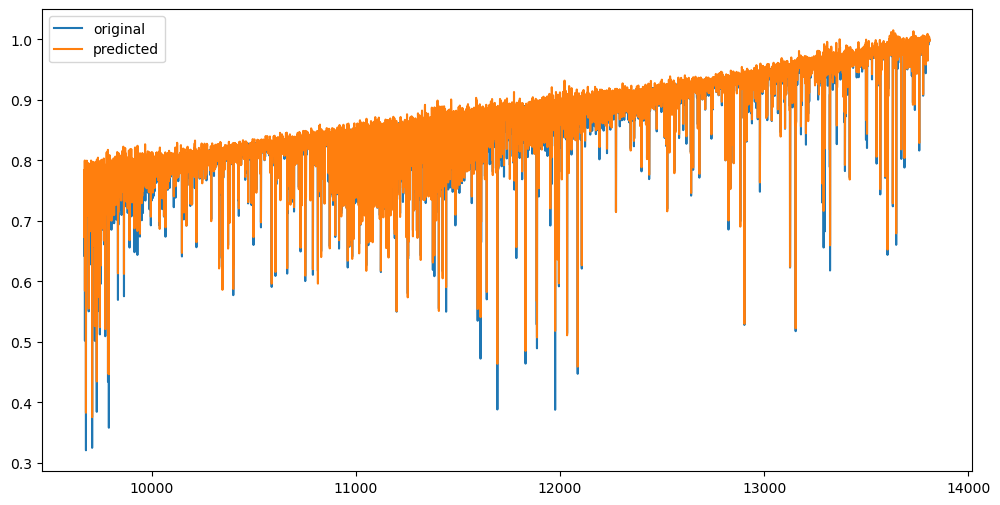

In [76]:
LEARNING_RATE = 1e-4
EPOCHS = 250000
BATCH_SIZE = 2048*2

def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)


def mse_pinball_loss_fn(model, x, y, tau=0.99):
    y_pred = jax.vmap(model)(x)
    mse = (y_pred - y)**2
    losses = jnp.where(mse>=0, tau*mse, (1-tau)*mse)
    return jnp.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, tau=0.99):
    loss, grads = eqx.filter_value_and_grad(mse_pinball_loss_fn)(model, x, y, tau)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

skey = jax.random.PRNGKey(43)
model = FDHO(n_in_coo=1, rkey=skey, num_hidden_layers=2, hidden_size=512, final_activation=jax.nn.identity) 
optimizer = optax.adam(learning_rate=LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

xs = jnp.array(model_wave_norm).reshape(-1, 1)
ys = ysdt

ysmax = ys.max()

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, tau=0.99)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


plt.figure(figsize=(12, 6))
ypred = jax.vmap(model)(xs)
ypreddt = ypred + (m*xs[:, 0] + b)
plt.plot(model_wave.value, model_flux_fnu_norm, label='original')
plt.plot(model_wave.value, ypreddt, label='predicted')
plt.legend()

In [79]:
jnp.std(model_flux_fnu_norm -ypreddt)

Array(0.01009853, dtype=float32)

Hmm, trains much better, is it fast enough?

In [77]:
vmod = jax.jit(jax.vmap(model))
ypred = vmod(xs)
%timeit vmod(xs)

258 μs ± 687 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Still seems like its overshooting the top...

Plenty of headroom for the multi-d case it seems